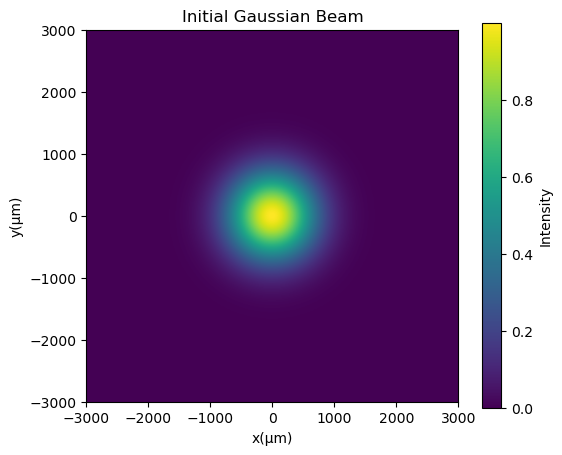

In [34]:
# 5.1 Initial Gaussian Beam
import numpy as np
import matplotlib.pyplot as plt

N = 512
L = 3000.0
wavelength = 0.633
z = 50.0
w0 = 1000
#previous 1.5

x1 = np.linspace(-L, L, N)
y1 = np.linspace(-L, L, N)
x, y = np.meshgrid(x1, y1)

dx = x[0,1] - x[0,0]
dy = y[1,0] - y[0,0]

#window = np.exp(-(x**2 + y**2) / (L*0.7)**2)
E0 = np.exp(-(x**2 + y**2) / w0**2) 

plt.figure(figsize=(6,5))
plt.imshow(np.abs(E0)**2, extent=[-L, L, -L, L], origin='lower')
plt.title("Initial Gaussian Beam")
plt.xlabel("x(μm)")
plt.ylabel("y(μm)")
plt.colorbar(label="Intensity")
plt.show()

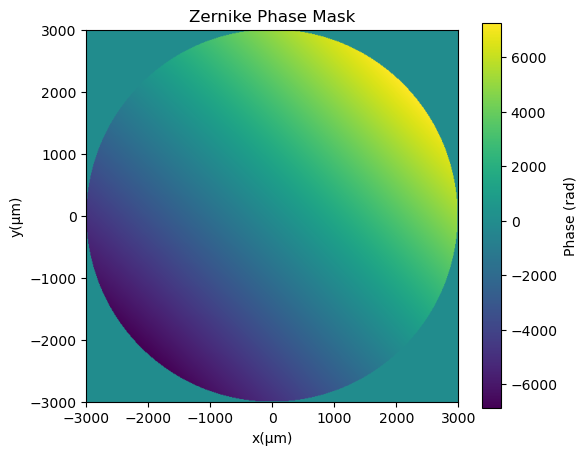

In [52]:
# 5.2 Phase Mask (Zernike)
r = np.sqrt(x**2 + y**2) / L
theta = np.arctan2(y, x)

# Aperture mask
mask = r <= 1

# Zernike modes
Z1 = r * np.cos(theta)             
Z2 = r * np.sin(theta)              
Z3 = 2 * r**2 - 1                   
Z4 = r**2 * np.cos(2 * theta)      
Z5 = r**2 * np.sin(2 * theta)       

# Zernike 
np.random.seed(42)
a1 = 5000
a2 = 5000
a3 = 100
a4 = 80
a5 = 80

# Phase screen
phi = a1*Z1 + a2*Z2 + a3*Z3 + a4*Z4 + a5*Z5
phi[~mask] = 0

plt.figure(figsize=(6,5))
plt.imshow(phi, extent=[-L, L, -L, L], origin='lower')
plt.title("Zernike Phase Mask")
plt.xlabel("x(μm)")
plt.ylabel("y(μm)")
plt.colorbar(label="Phase (rad)")
plt.show()

phase_mask = np.exp(1j * phi)

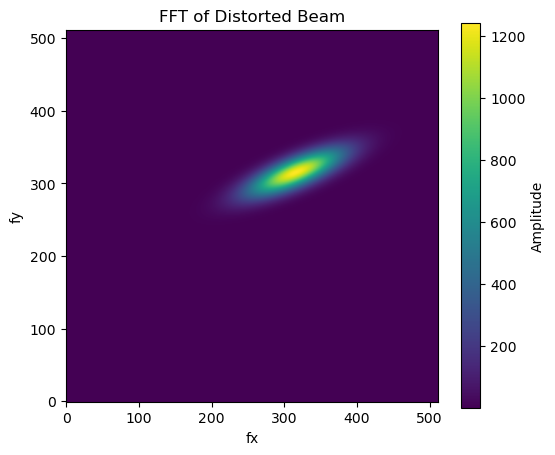

In [53]:
# 5.3 FFT Propagation
E_distorted = E0 * phase_mask
E_fft = np.fft.fftshift(np.fft.fft2(E_distorted))

plt.figure(figsize=(6,5))
plt.imshow(np.abs(E_fft), origin='lower')
plt.title("FFT of Distorted Beam")
plt.xlabel("fx")
plt.ylabel("fy")
plt.colorbar(label="Amplitude")
plt.show()

fx = np.fft.fftshift(np.fft.fftfreq(N, d=dx))
fy = np.fft.fftshift(np.fft.fftfreq(N, d=dy))
FX, FY = np.meshgrid(fx, fy)


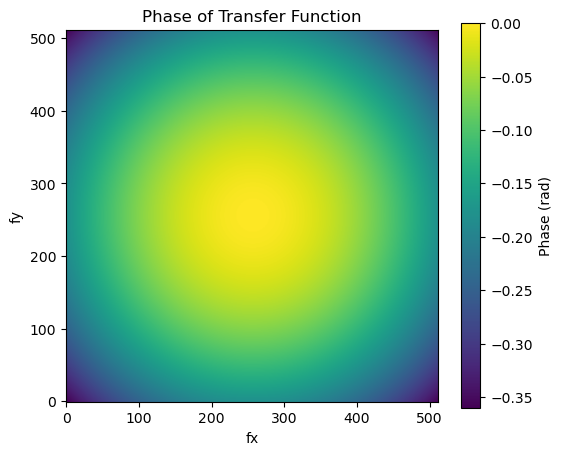

In [54]:
fx = np.fft.fftshift(np.fft.fftfreq(N, d=dx))
fy = np.fft.fftshift(np.fft.fftfreq(N, d=dy))
FX, FY = np.meshgrid(fx, fy)

H = np.exp(-1j * np.pi * wavelength * z * (FX**2 + FY**2))

plt.figure(figsize=(6,5))
plt.imshow(np.angle(H), origin='lower')
plt.title("Phase of Transfer Function")
plt.xlabel("fx")
plt.ylabel("fy")
plt.colorbar(label="Phase (rad)")
plt.show()

E_fft_prop = E_fft * H

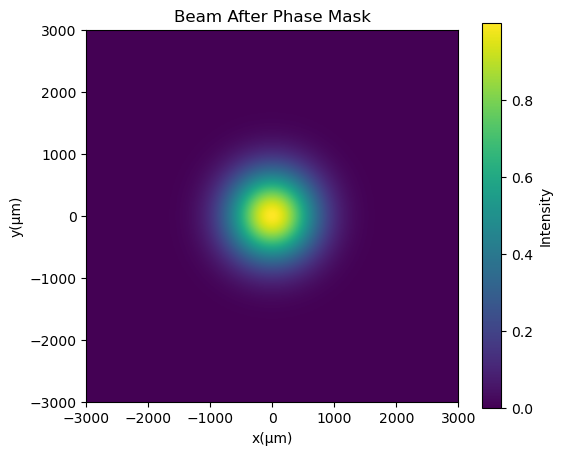

In [55]:

# 5.4 Distorted Beam
# 5.4.1

plt.figure(figsize=(6,5))
plt.imshow(np.abs(E_distorted)**2, extent=[-L, L, -L, L], origin='lower')
plt.title("Beam After Phase Mask")
plt.xlabel("x(μm)")
plt.ylabel("y(μm)")
plt.colorbar(label="Intensity")
plt.show()


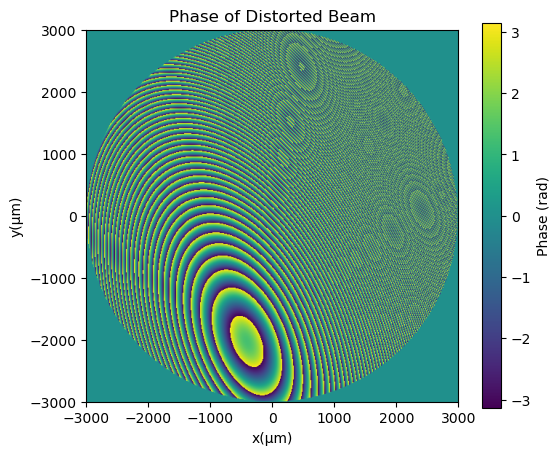

In [56]:
#5.4.2 
plt.figure(figsize=(6,5))
plt.imshow(np.angle(E_distorted), extent=[-L, L, -L, L], origin='lower')
plt.title("Phase of Distorted Beam")
plt.xlabel("x(μm)")
plt.ylabel("y(μm)")
plt.colorbar(label="Phase (rad)")
plt.show()

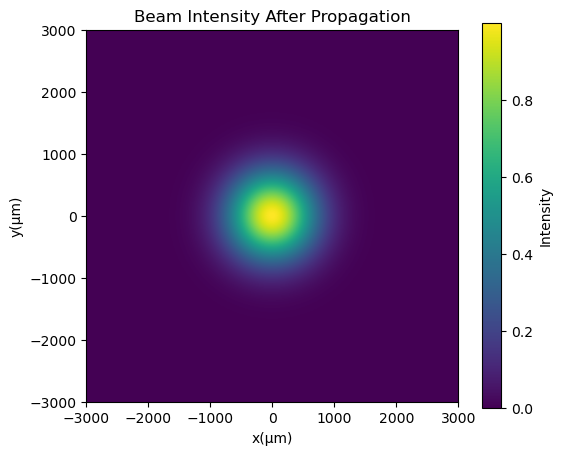

In [57]:
# 5.5 Comparison
E_out = np.fft.ifft2(np.fft.ifftshift(E_fft_prop))
plt.figure(figsize=(6,5))
plt.imshow(np.abs(E_out)**2, extent=[-L, L, -L, L], origin='lower')
plt.title("Beam Intensity After Propagation")
plt.xlabel("x(μm)")
plt.ylabel("y(μm)")
plt.colorbar(label="Intensity")
plt.show()